In [33]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers

In [ ]:
IMG_SIZE = 180
BATCH_SIZE = 32

(ds_train, ds_valid), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes

In [47]:
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)


# Conver to np arrays 
X_train = []
y_train = []

for image, label in tfds.as_numpy(ds_train):
    X_train.append(image)
    y_train.append(label)

X_valid = []
y_valid = []

for image, label in tfds.as_numpy(ds_valid):
    X_valid.append(image)
    y_valid.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_valid = np.array(X_valid)
y_valid = np.array(y_valid)

for x, y in ds_train.take(1):
    print("X shape:", x.shape)
    print("Y shape:", y.shape)


X shape: (180, 180, 3)
Y shape: ()


In [10]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

tf.random.set_seed(42)  # extra code – for reproducibility

In [18]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(180, 180, 3)),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

c:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 204ms/step - accuracy: 0.2514 - loss: 6.0987 - val_accuracy: 0.2166 - val_loss: 5.7645
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.2517 - loss: 5.5342 - val_accuracy: 0.2166 - val_loss: 5.3366


In [20]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(180, 180, 3)),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [24]:
# compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.2217 - loss: 1.8745 - val_accuracy: 0.2166 - val_loss: 1.6280
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.2292 - loss: 1.6485 - val_accuracy: 0.2534 - val_loss: 1.6050
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 0.2360 - loss: 1.6216 - val_accuracy: 0.3065 - val_loss: 1.5959
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.2337 - loss: 1.6156 - val_accuracy: 0.3065 - val_loss: 1.5874
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.2606 - loss: 1.6009 - val_accuracy: 0.3120 - val_loss: 1.5720
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.2708 - loss: 1.5826 - val_accuracy: 0.3379 - val_loss: 1.5512
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 199ms/step - accuracy: 0.2878 - loss: 1.5675 - val_accuracy: 0.3447 - val_loss: 1.5319
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step - accuracy: 0.3021 - loss: 1.5401 - val_accu

In [49]:
IMG_SIZE = 180
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

(ds_train, ds_valid), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
print("Number of classes:", NUM_CLASSES)

# Preprocess the datasets
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Suffle and batch the datasets
ds_train = (
    ds_train
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_valid = (
    ds_valid
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Number of classes: 5


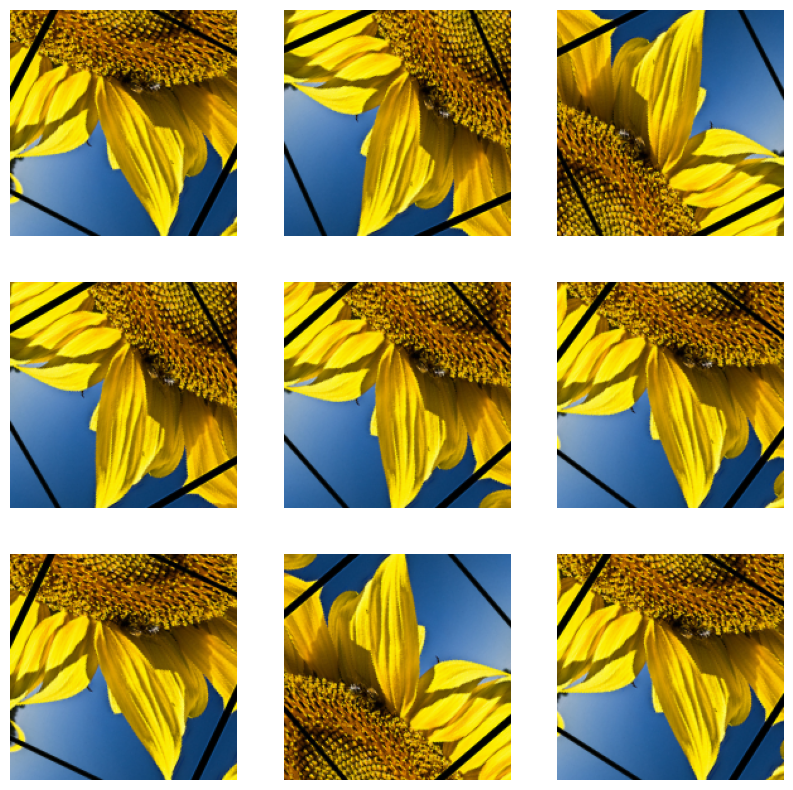

In [53]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Add the image to a batch.
image = tf.cast(tf.expand_dims(image, 0), tf.float32)

plt.figure(figsize=(10, 10))
for i in range(9):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(augmented_image[0])
  plt.axis("off")

In [51]:
def build_augmented_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        data_augmentation,  # only active during training

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])

In [52]:
model = build_augmented_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4550 - loss: 1.2960 - val_accuracy: 0.5763 - val_loss: 1.0730
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 91s 988ms/step - accuracy: 0.5869 - loss: 1.0405 - val_accuracy: 0.6308 - val_loss: 0.9616
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 850ms/step - accuracy: 0.6383 - loss: 0.9169 - val_accuracy: 0.6744 - val_loss: 0.8592
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 921ms/step - accuracy: 0.6778 - loss: 0.8343 - val_accuracy: 0.6717 - val_loss: 0.8431
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 926ms/step - accuracy: 0.6911 - loss: 0.7953 - val_accuracy: 0.6894 - val_loss: 0.7960
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 896ms/step - accuracy: 0.7214 - loss: 0.7222 - val_accuracy: 0.7425 - val_loss: 0.6966
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7428 - loss: 0.6989 - val_accuracy: 0.7302 - val_loss: 0.6904
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 922ms/step - accuracy: 0.7548 - loss: 0.6575 - val_accuracy: